In [1]:
import torch

In [2]:
import timm
import torch.nn as nn
import cv2
import numpy as np

/home/chris/miniconda3/envs/fungiclef/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
weights = torch.load("DF20-ViT_large_patch16_224_best_accuracy.pth")

In [4]:
weights['module.cls_token'].shape

torch.Size([1, 1, 1024])

In [5]:
weights['module.pos_embed'].shape

torch.Size([1, 197, 1024])

In [6]:
weights['module.patch_embed.proj.weight'].shape

torch.Size([1024, 3, 16, 16])

In [7]:
weights['module.head.weight']

tensor([[ 0.0310, -0.0352,  0.0751,  ..., -0.0039, -0.0461, -0.0960],
        [-0.0178, -0.0068,  0.0533,  ..., -0.0105, -0.0454,  0.0029],
        [-0.0337,  0.0115, -0.0554,  ...,  0.0089,  0.0321, -0.0280],
        ...,
        [ 0.0562, -0.0940, -0.0069,  ..., -0.0086,  0.0049, -0.0557],
        [ 0.0068, -0.0564,  0.0424,  ..., -0.0533, -0.0816, -0.0014],
        [-0.0287, -0.0639, -0.0695,  ..., -0.0553, -0.0429, -0.0153]],
       device='cuda:0')

In [8]:
def getModel(architecture_name, target_size, pretrained = False):
    net = timm.create_model(architecture_name, pretrained=pretrained)
    net_cfg = net.default_cfg
    last_layer = net_cfg['classifier']
    num_ftrs = getattr(net, last_layer).in_features
    setattr(net, last_layer, nn.Linear(num_ftrs, target_size))
    return net

In [9]:
MODEL_NAME = 'vit_large_patch16_224'
model = getModel(MODEL_NAME, 1604, pretrained=False)

In [10]:
n_weights = {k.replace("module.", ""): v for k, v in weights.items()}

In [11]:
model.load_state_dict(n_weights)

<All keys matched successfully>

In [12]:
from torch.utils.data import DataLoader, Dataset

In [13]:
import pandas as pd

In [14]:
class FungiClefDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        file_path = self.df['image_path'].values[idx]
        label = self.df['class_id'].values[idx]
        image =  np.frombuffer(df['im_bytes'][idx], dtype='uint8').reshape((df['im_height'][idx],df['im_widgth'][idx], 3))

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        
        return image, label

In [15]:
model_mean = list(model.default_cfg['mean'])
model_std = list(model.default_cfg['std'])

In [16]:
from albumentations import Compose, Normalize, Resize
from albumentations.pytorch import ToTensorV2

In [17]:
HEIGHT = 224
WIDTH = 224
transform = Compose([
            Resize(WIDTH, HEIGHT),
            Normalize(mean=model_mean, std=model_std),
            ToTensorV2(),
        ])

In [18]:
df = pd.read_parquet("dev_train.parquet")

In [19]:
img = np.frombuffer(df['im_bytes'][0], dtype='uint8').reshape((df['im_height'][0],df['im_widgth'][0], 3))

In [20]:
df['image_path'][0]

'2238493461-243975.JPG'

In [21]:
img = cv2.imread("data/DF20_300/{path}".format(path=df['image_path'][0].replace("JPG", "jpg")))
        

In [22]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


In [23]:
import matplotlib.pyplot as plt

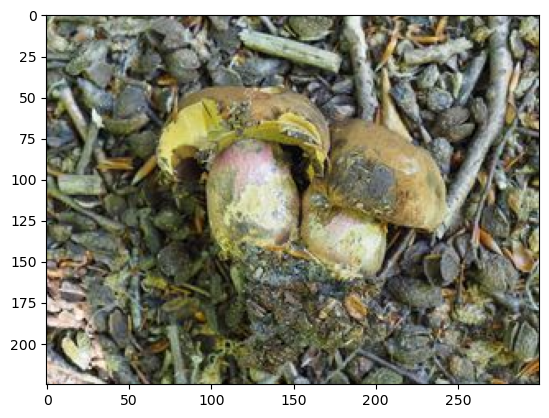

In [24]:
plt.imshow(img)

In [25]:
type(df['im_bytes'][0])

bytes

In [27]:
ds = FungiClefDataset(df, transform)

In [29]:
loader = DataLoader(ds, batch_size=8, shuffle=False, num_workers=4)

In [30]:
import tqdm

In [31]:
from sklearn.metrics import f1_score

In [46]:
df

,observationID,year,month,day,countryCode,locality,taxonID,scientificName,kingdom,phylum,...,Longitude,CoorUncert,Habitat,image_path,class_id,MetaSubstrate,poisonous,im_height,im_widgth,im_bytes
0,2238493461,2017.0,6.0,18.0,DK,Frederiksdal Skov,65789.0,"Neoboletus luridiformis (Rostk.) Gelardi, Simo...",Fungi,Basidiomycota,...,12.431540,2500.0,Deciduous woodland,2238493461-243975.JPG,1023,jord,0,225,300,b'\x9e\xb9\xa8\x9c\xb4\xa4\x93\xa4\x94\xba\xc5...
1,2458347254,2019.0,11.0,23.0,DK,Pedersker Plantage,65789.0,"Neoboletus luridiformis (Rostk.) Gelardi, Simo...",Fungi,Basidiomycota,...,15.006622,45.0,Unmanaged coniferous woodland,2458347254-125557.JPG,1023,mosses,0,400,300,b'\r#!\x0f%#\x1b1.+A>1FA+@;\'>6+B:/I>2NB6RD2RC...
2,2274829785,2019.0,7.0,12.0,DK,Tversted Plantage,11064.0,"Imleria badia (Fr.) Vizzini, 2014",Fungi,Basidiomycota,...,10.235952,75.0,Mixed woodland (with coniferous and deciduous ...,2274829785-189471.JPG,711,jord,0,241,300,"b'.40(/(!+# , !-!\x1e/\x1f 1\x1f#6#2E1L_Kbuak~..."
3,2874317542,2020.0,10.0,11.0,DK,Kellers Park,15815.0,Lactarius blennius (Fr.) Fr.,Fungi,Basidiomycota,...,9.691423,5.0,Unmanaged deciduous woodland,2874317542-364866.JPG,764,plant material,0,169,300,b'GNTCJPDIOFKQJMTHKRA@F98>83:;6=C9AG=EH;B?294%...
4,2862684460,2020.0,9.0,20.0,DK,Tørsbøl,10252.0,"Amanita muscaria (L.) Lam., 1783",Fungi,Basidiomycota,...,9.489764,65.0,Unmanaged coniferous woodland,2862684460-211102.JPG,42,wood,1,400,300,"b'OQP,.-/1.OQNTUPFGA@?:==5IF=NL@C<2;5)H@3KC6D=..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3709,2847211315,2020.0,8.0,12.0,DK,Svalhøje,20024.0,Russula ochroleuca (Pers.) Fr.,Fungi,Basidiomycota,...,8.533502,50.0,Mixed woodland (with coniferous and deciduous ...,2847211315-209496.JPG,1357,jord,0,225,300,b'PVJ`h[[cXkwky\x85{o\x7ftu\x85zo\x81sr\x84vr\...
3710,2868486302,2020.0,9.0,27.0,DK,Skodsborg,11064.0,"Imleria badia (Fr.) Vizzini, 2014",Fungi,Basidiomycota,...,12.553811,11.0,Unmanaged coniferous woodland,2868486302-363573.JPG,711,plant material,0,400,300,b'qN8rO9tQ;vS=xU?yV@zWAzWAuR<uR<uR<uR<sP:qN8oL...
3711,2238492945,2017.0,6.0,3.0,DK,Hobro Østerskov,65789.0,"Neoboletus luridiformis (Rostk.) Gelardi, Simo...",Fungi,Basidiomycota,...,9.849200,50.0,Unmanaged deciduous woodland,2238492945-169928.JPG,1023,jord,0,225,300,b'1-*OKHuqn}yvkgdfb_rmjxspWOMi_^\x88}{sedlZZr`...
3712,2901937415,2020.0,10.0,28.0,DK,Kulhus By,10252.0,"Amanita muscaria (L.) Lam., 1783",Fungi,Basidiomycota,...,11.912809,65.0,lawn,2901937415-217660.JPG,42,jord,1,400,300,b'zxl\x9a\x9a\x8e\x92\x92\x88[^SWZOZ`TjreYaTy\...


In [32]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Id

In [34]:
f1_scores = []

In [45]:
df.poisonous.value_counts()

poisonous
0    2947
1     767
Name: count, dtype: int64

In [35]:
for i, (images, labels) in tqdm.tqdm(enumerate(loader)):
    images = images.to(device)
    labels = labels.to(device)
    
    with torch.no_grad():
        y_preds = model(images)
    y_preds = model(images)
    
    f1_scores.append(f1_score(labels.to('cpu').numpy(), y_preds.argmax(1).to('cpu').numpy(), average="macro"))

465it [00:29, 15.55it/s]


In [38]:
np.mean(f1_scores)

0.940083126636122

In [107]:
labels

tensor([1357,  711, 1357,   42,   42, 1023,  764,  711])

### TODO: 
1. Add metadata to training as well (?) - Replace the head or something
2. Try on the hard to classify stuff (that's the danger zone!)
3. This model is > 1GB. Need something smaller (but equally performant). Can we just quantize this current model and call it a day? LOL

OrderedDict([('module.cls_token',
              tensor([[[-0.0055,  0.0973, -0.0306,  ...,  0.0298, -0.0124, -0.0323]]],
                     device='cuda:0')),
             ('module.pos_embed',
              tensor([[[-0.0055,  0.0973, -0.0306,  ...,  0.0298, -0.0124, -0.0323],
                       [ 0.0408, -0.0027,  0.0124,  ...,  0.0542, -0.0100, -0.0116],
                       [ 0.0265,  0.0021, -0.0050,  ...,  0.0744, -0.0076,  0.0073],
                       ...,
                       [ 0.0256, -0.0068, -0.0213,  ..., -0.0164,  0.0048,  0.0286],
                       [ 0.0081, -0.0082, -0.0036,  ..., -0.0442,  0.0193,  0.0108],
                       [ 0.0010,  0.0015, -0.0081,  ..., -0.0377,  0.0327, -0.0137]]],
                     device='cuda:0')),
             ('module.patch_embed.proj.weight',
              tensor([[[[-2.7308e-02, -3.6148e-02, -2.4295e-02,  ..., -1.9518e-02,
                         -3.2941e-02, -3.9826e-03],
                        [-3.3698e-02, -3.8